# 01 - Exploring The Datasets

This notebook is the first step in analyzing and understanding the datasets collected for the Bologna Synthetic Mobility project. The goal is to get a comprehensive overview of the data, inspect their structure, check for missing values, and understand the basic distributions and relationships before proceeding to data cleaning, integration, and modeling.

We will:

1. **Load all cleaned datasets** from the `data/interim/` folder.
2. **Inspect each dataset** individually:
   - Check columns, data types, and basic statistics.
   - Identify the range of years covered.
   - Look for missing or unusual values.
3. **Perform initial exploratory analysis**:
   - Summarize distributions (e.g., population counts, household sizes, incomes).
   - Compare key totals across datasets (e.g., total residents vs. total household components).
   - Visualize patterns where informative (histograms, bar charts, etc.).
4. **Note observations** that might inform later processing, feature engineering, or modeling decisions.

This notebook is intended as a **reference point for understanding the data** before building the synthetic population and mobility models.


### Area Hierarchy

Datasets are organized by geographic areas. The hierarchy is as follows:

- **Sezione di Censimento (Census Section)** - the smallest statistical unit defined by ISTAT, consisting each of a few blocks
- **Area** – the smallest official municipal statistical unit used for most analyses (~**90 areas**).
- **Zona** – a neighborhood grouping of multiple areas (~**18 zones** ).
- **Quartiere** – a larger district composed of multiple zones (~**6 quartieri**).

We have created a **spatial lookup table** using our cleaning scripts to map areas to their corresponding zones and quartieri. This ensures that all datasets can be joined consistently, even if some datasets report only areas, zones, or quartieri.

For most our purposes, we will use Aree Statistiche, e.g. Area spatial unit. for some datasets we might need to aggregate or disaggregate.

### Datasets to Explore

1. **Demographics** (`data/interim/demographics.csv`) – population by sex, age group, and citizenship.
2. **Households** (`data/interim/households.csv`) – household type, household size, number of households, and total components.
3. **Income** (`data/interim/income.csv`) – taxpayers, taxable income, and average income per area.
4. **Occupation** (`data/interim/occupation.csv`) – number of local units, private and public workers, and students per area.

We will start by loading each dataset, inspecting its structure, and checking the key statistics, such as totals, distributions, and missing values. Visualizations will help identify patterns and potential inconsistencies across datasets.


In [1]:
# ============================================================
# 01_explore_datasets
# Import required libraries
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries successfully loaded.")


Libraries successfully loaded.


In [2]:
# ============================================================
# Define project paths
# ============================================================

PROJECT_ROOT = Path().resolve().parent
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"

print("Project root:", PROJECT_ROOT)
print("Interim data folder:", DATA_INTERIM)


Project root: /Users/maryamriazi/Documents/bologna-synthetic-mobility
Interim data folder: /Users/maryamriazi/Documents/bologna-synthetic-mobility/data/interim


In [3]:
# ============================================================
# Load cleaned datasets
# ============================================================

demographics = pd.read_csv(DATA_INTERIM / "demographics_clean.csv")
households   = pd.read_csv(DATA_INTERIM / "households.csv")
income       = pd.read_csv(DATA_INTERIM / "income.csv")
occupation   = pd.read_csv(DATA_INTERIM / "occupation_2years.csv")
activity = pd.read_csv("../data/interim/destination_activity_2023.csv")

print("Datasets loaded successfully.\n")

print("Demographics shape:", demographics.shape)
print("Households shape:", households.shape)
print("Income shape:", income.shape)
print("Occupation shape:", occupation.shape)


Datasets loaded successfully.

Demographics shape: (3347, 8)
Households shape: (709, 6)
Income shape: (92, 5)
Occupation shape: (4236, 9)


## 1. Demographics Dataset

This section explores the cleaned demographics dataset, which contains population information at the Area Statistica level.

We examine its structure, spatial coverage, and key aggregates (total population and distribution across Quartieri) to verify internal consistency and alignment with official statistics.

The goal is to understand how population is distributed spatially before integrating this dataset with households, income, and occupation data.


In [4]:
# ============================================================
# Demographics – Structure Overview
# ============================================================

print("Shape:", demographics.shape)
print("\nColumns:")
print(demographics.columns)

print("\nInfo:")
demographics.info()

print("\nHead:")
display(demographics.head(10))


Shape: (3347, 8)

Columns:
Index(['area_id', 'area_name', 'quartiere_name', 'zona_name', 'sex', 'age_group', 'citizenship', 'population'], dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 3347 entries, 0 to 3346
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   area_id         3347 non-null   int64
 1   area_name       3347 non-null   str  
 2   quartiere_name  3347 non-null   str  
 3   zona_name       3347 non-null   str  
 4   sex             3347 non-null   str  
 5   age_group       3347 non-null   str  
 6   citizenship     3347 non-null   str  
 7   population      3347 non-null   int64
dtypes: int64(2), str(6)
memory usage: 209.3 KB

Head:


,area_id,area_name,quartiere_name,zona_name,sex,age_group,citizenship,population
0,99,non indicata,Senza fissa dimora,Senza fissa dimora,Maschi,02 e prima,Straniera,1
1,99,non indicata,Senza fissa dimora,Senza fissa dimora,Maschi,06-14,Straniera,2
2,99,non indicata,Senza fissa dimora,Senza fissa dimora,Maschi,25-34,Italiana,5
3,99,non indicata,Senza fissa dimora,Senza fissa dimora,Maschi,55-64,Italiana,123
4,99,non indicata,Senza fissa dimora,Senza fissa dimora,Maschi,65 e oltre,Italiana,88
5,1,Lavino di Mezzo,Borgo Panigale - Reno,Borgo Panigale,Maschi,15-24,Straniera,5
6,1,Lavino di Mezzo,Borgo Panigale - Reno,Borgo Panigale,Maschi,65 e oltre,Italiana,33
7,3,Bargellino,Borgo Panigale - Reno,Borgo Panigale,Femmine,06-14,Italiana,2
8,4,Aeroporto,Borgo Panigale - Reno,Borgo Panigale,Maschi,02 e prima,Italiana,4
9,4,Aeroporto,Borgo Panigale - Reno,Borgo Panigale,Maschi,25-34,Italiana,14


In [5]:
# ============================================================
# Demographics – Spatial Coverage
# ============================================================

print("Unique Quartieri:", demographics['quartiere_name'].nunique())
print("Unique Zone:", demographics['zona_name'].nunique())
print("Unique Areas:", demographics['area_name'].nunique())


Unique Quartieri: 7
Unique Zone: 19
Unique Areas: 91


We have one more than standard for each; considering there are 6 Quartieri, 18 Zones, and 90 Areas.

So each one has one more, which is probably unidentified. We need to inspect this.

In [6]:
# ============================================================
# Inspect unique spatial labels
# ============================================================

print("Quartieri:")
print(sorted(demographics['quartiere_name'].unique()))

print("\nZone:")
print(sorted(demographics['zona_name'].unique()))

print("\nAreas:")
print(sorted(demographics['area_name'].unique()))


Quartieri:
['Borgo Panigale - Reno', 'Navile', 'Porto - Saragozza', 'San Donato - San Vitale', 'Santo Stefano', 'Savena', 'Senza fissa dimora']

Zone:
['Barca', 'Bolognina', 'Borgo Panigale', 'Colli', 'Corticella', 'Costa Saragozza', 'Galvani', 'Irnerio', 'Lame', 'Malpighi', 'Marconi', 'Mazzini', 'Murri', 'Saffi', 'San Donato', 'San Ruffillo', 'San Vitale', 'Santa Viola', 'Senza fissa dimora']

Areas:
['Aeroporto', 'Agucchi', 'Arcoveggio', 'Bargellino', 'Battindarno', 'Beverara', 'Bitone', 'Borgo Centro', 'CAAB', 'CNR', 'Cadriano-Calamosco', 'Canale di Reno', 'Caserme Rosse-Manifattura', 'Casteldebole', 'Cavedone', 'Chiesanuova', 'Cirenaica', 'Corelli', 'Croce Coperta', 'Croce del Biacco', 'Dagnini', 'Ducati-Villaggio Ina', 'Due Madonne', 'Emilia Ponente', 'Ex Mercato Ortofrutticolo', 'Fiera', 'Fossolo', 'Galvani-1', 'Galvani-2', 'Giardini Margherita', 'Guelfa', 'Irnerio-1', 'Irnerio-2', 'La Birra', 'La Dozza', 'La Noce', 'Laghetti del Rosario', 'Lavino di Mezzo', 'Lazzaretto', 'Lungo 

In [7]:
# ============================================================
# Size of "Senza fissa dimora" and "non indicata"
# ============================================================


# Total Population
total_population = demographics['population'].sum()
print("Total population:", total_population)

# Quartiere level
sfd_quartiere = demographics[demographics['quartiere_name'] == 'Senza fissa dimora']
print("Rows (Quartiere - Senza fissa dimora):", len(sfd_quartiere))
print("Population (Quartiere - Senza fissa dimora):", sfd_quartiere['population'].sum())

# Zona level
sfd_zona = demographics[demographics['zona_name'] == 'Senza fissa dimora']
print("\nRows (Zona - Senza fissa dimora):", len(sfd_zona))
print("Population (Zona - Senza fissa dimora):", sfd_zona['population'].sum())

# Area level
non_indicata = demographics[demographics['area_name'] == 'non indicata']
print("\nRows (Area - non indicata):", len(non_indicata))
print("Population (Area - non indicata):", non_indicata['population'].sum())


Total population: 392791
Rows (Quartiere - Senza fissa dimora): 38
Population (Quartiere - Senza fissa dimora): 747

Rows (Zona - Senza fissa dimora): 38
Population (Zona - Senza fissa dimora): 747

Rows (Area - non indicata): 38
Population (Area - non indicata): 747


In [8]:
percentage = non_indicata['population'].sum() / total_population * 100
print(f"Percentage of total population: {percentage:.3f}%")


Percentage of total population: 0.190%


#### Note on “Senza fissa dimora”

The dataset includes 747 residents (0.19% of total population) classified as *Senza fissa dimora* (without fixed residence), corresponding to “non indicata” at Area level.

Since these individuals cannot be spatially assigned to a specific Area Statistica, they are excluded from spatial aggregation analyses but retained in total population counts.


In [9]:
# ============================================================
# Exclude "Senza fissa dimora" / "non indicata"
# ============================================================

demographics = demographics[
    ~( (demographics['quartiere_name'] == 'Senza fissa dimora') |
       (demographics['zona_name'] == 'Senza fissa dimora') |
       (demographics['area_name'] == 'non indicata') )
].copy()

print("Rows after filtering:", len(demographics))
print("Population after filtering:", demographics['population'].sum())


Rows after filtering: 3309
Population after filtering: 392044


In [10]:
# ============================================================
# Inspect unique sexes and age groups
# ============================================================

print("Unique sexes:", demographics['sex'].unique())
print("Number of unique sexes:", demographics['sex'].nunique())

print("\nUnique age groups:", demographics['age_group'].unique())
print("Number of unique age groups:", demographics['age_group'].nunique())


Unique sexes: <StringArray>
['Maschi', 'Femmine']
Length: 2, dtype: str
Number of unique sexes: 2

Unique age groups: <StringArray>
['15-24', '65 e oltre', '06-14', '02 e prima', '25-34', '03-05', '55-64', '45-54', '35-44']
Length: 9, dtype: str
Number of unique age groups: 9


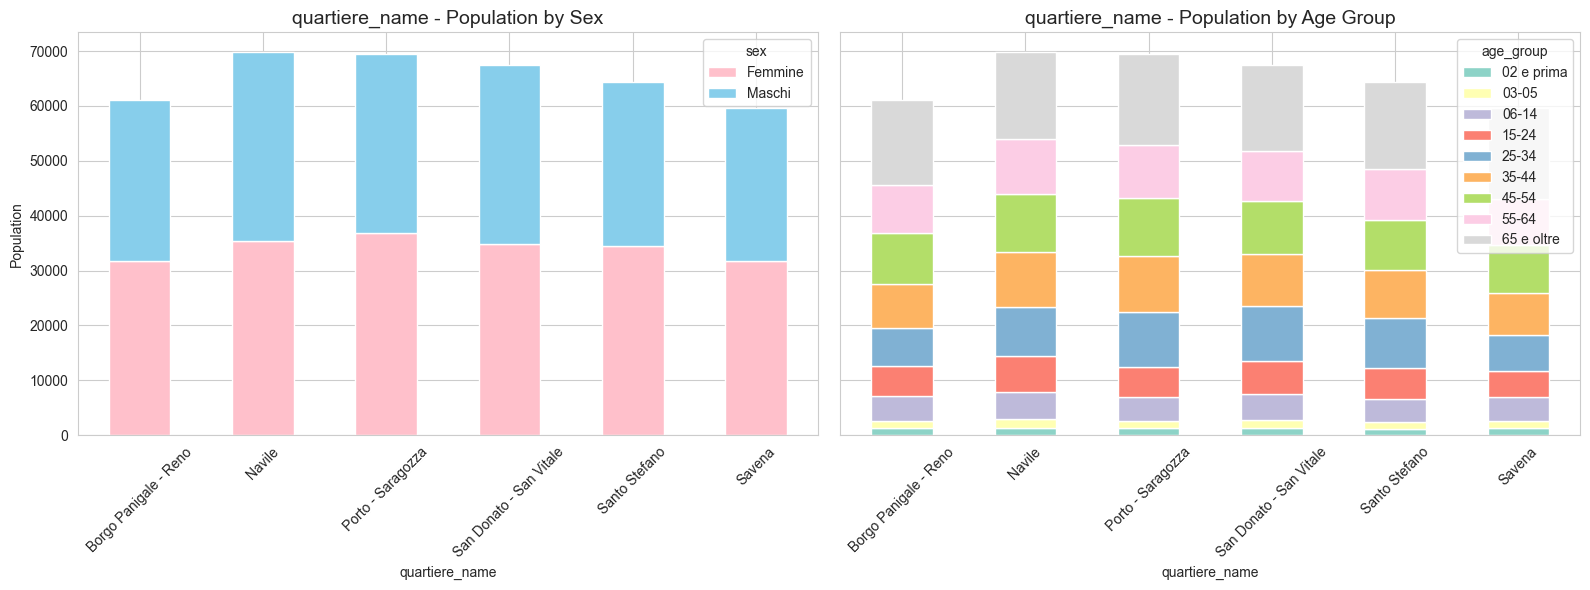

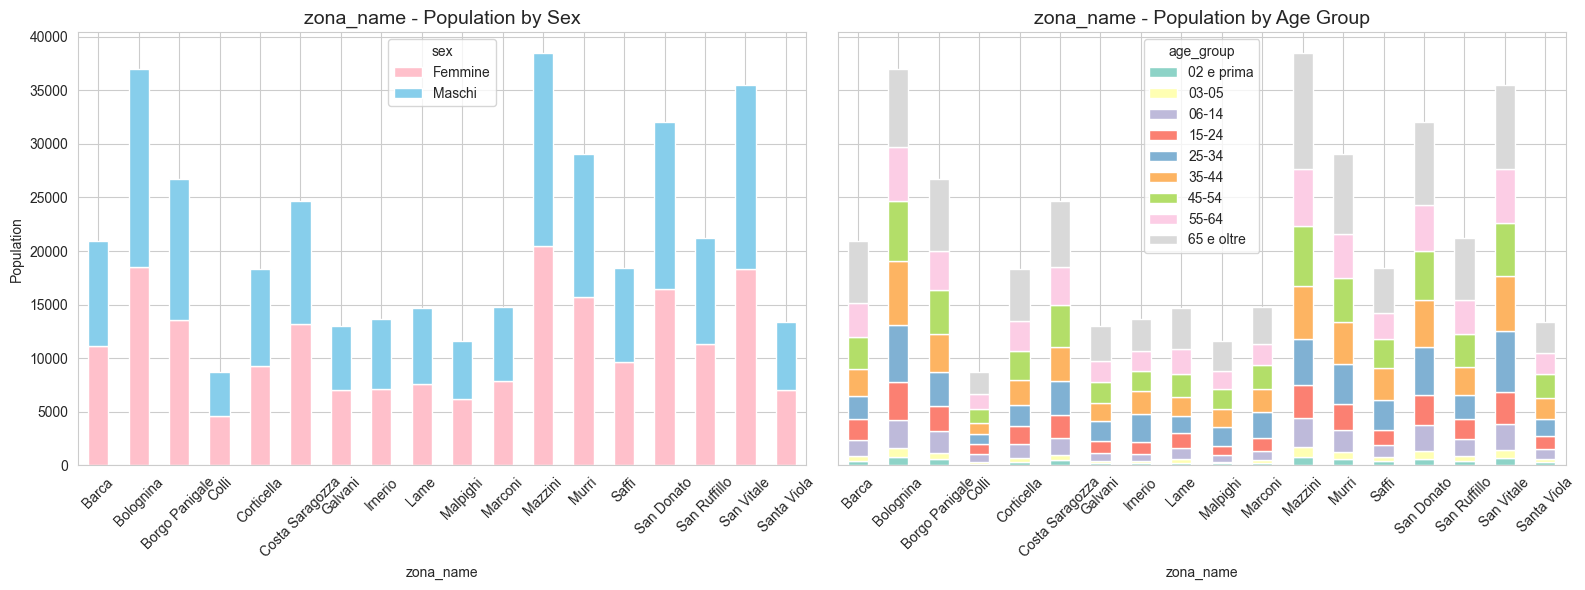

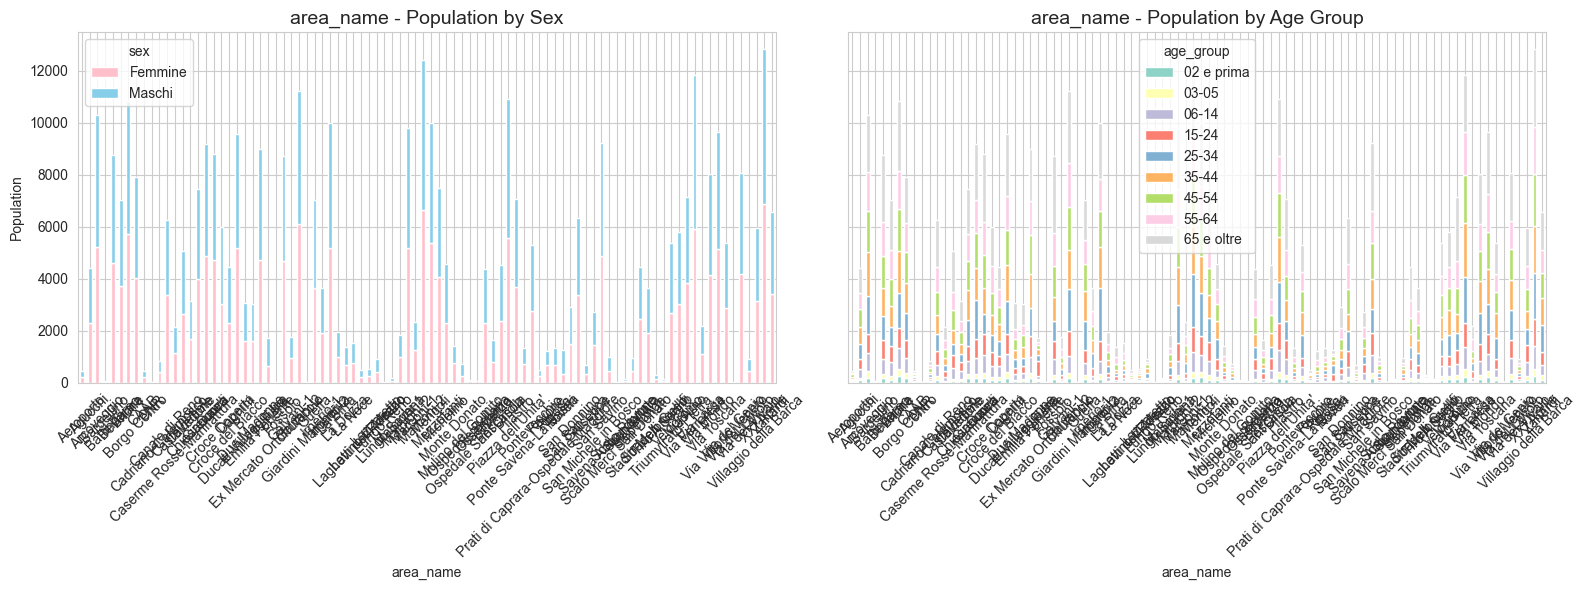

In [11]:
# ============================================================
# Population stacked bar plots (Sex and Age Group)
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Palettes
sex_palette = {'Maschi':'skyblue', 'Femmine':'pink'}
age_groups_ordered = ['02 e prima', '03-05', '06-14', '15-24', '25-34', '35-44', '45-54', '55-64', '65 e oltre']
age_palette = sns.color_palette("Set3", len(age_groups_ordered))

# Make age_group categorical
demographics['age_group'] = pd.Categorical(
    demographics['age_group'], categories=age_groups_ordered, ordered=True
)

# Create folder for figures
FIG_DIR = Path("../results/figures") 
FIG_DIR.mkdir(parents=True, exist_ok=True)


# Function to create dual stacked bar plots
def plot_dual_stacked(df, group_col):
    # Aggregate
    data_sex = df.groupby([group_col, 'sex'])['population'].sum().unstack(fill_value=0)
    data_age = df.groupby([group_col, 'age_group'])['population'].sum().unstack(fill_value=0)
    
    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)
    
    data_sex.plot(kind='bar', stacked=True, color=[sex_palette.get(x, "gray") for x in data_sex.columns], ax=axes[0])
    axes[0].set_title(f"{group_col} - Population by Sex", fontsize=14)
    axes[0].set_xlabel(group_col)
    axes[0].set_ylabel("Population")
    axes[0].tick_params(axis='x', rotation=45)
    
    data_age.plot(kind='bar', stacked=True, color=age_palette, ax=axes[1])
    axes[1].set_title(f"{group_col} - Population by Age Group", fontsize=14)
    axes[1].set_xlabel(group_col)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    
    # Save figure before showing
    fig_path = FIG_DIR / f"{group_col}_population_stacked.png"
    fig.savefig(fig_path, dpi=300)
    
    plt.show()
    plt.close(fig)


# Generate and save plots for all units
for unit in ['quartiere_name', 'zona_name', 'area_name']:
    plot_dual_stacked(demographics, unit)


Total geometries in Aree: 90
Total geometries in Zone: 18

--- Merge Validation ---
Aree with population: 90
Zone with population: 18


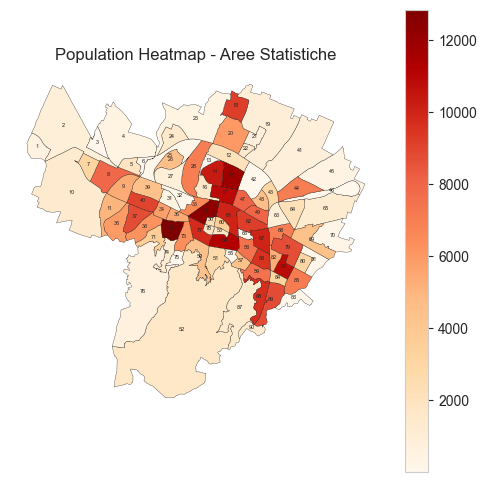

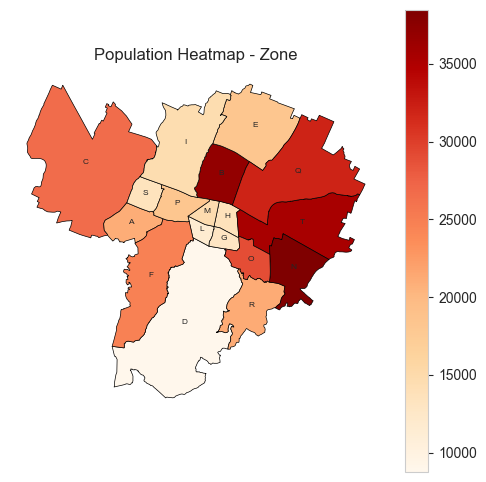

In [12]:
# ============================================================
# Population Heatmaps (Choropleth) 
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import unicodedata

# -----------------------------
# Paths
# -----------------------------
AREE_PATH = Path("../data/raw/spatial/aree_statistiche.geojson")
ZONE_PATH = Path("../data/raw/spatial/zone.geojson")

# -----------------------------
# Load
# -----------------------------
gdf_aree = gpd.read_file(AREE_PATH)
gdf_zone = gpd.read_file(ZONE_PATH)

print("Total geometries in Aree:", len(gdf_aree))
print("Total geometries in Zone:", len(gdf_zone))

# -----------------------------
# Aggregate population
# -----------------------------
pop_area = demographics.groupby("area_name")["population"].sum().reset_index()
pop_zona = demographics.groupby("zona_name")["population"].sum().reset_index()

# -----------------------------
# Normalization
# -----------------------------
def normalize(series):
    return (
        series
        .str.lower()
        .str.strip()
        .str.replace("santa ", "san ", regex=False)
        .str.replace("sant'", "san ", regex=False)
        .str.replace("sant ", "san ", regex=False)
        .str.replace("s. ", "san ", regex=False)
        .str.replace("s.", "san", regex=False)
        .apply(lambda x: unicodedata.normalize("NFKD", x))
        .str.encode("ascii", errors="ignore")
        .str.decode("utf-8")
        .str.replace("'", "", regex=False)
        .str.replace("-", " ", regex=False)
        .str.replace("  ", " ", regex=False)
    )

pop_area["norm"] = normalize(pop_area["area_name"])
gdf_aree["norm"] = normalize(gdf_aree["area_statistica"])

pop_zona["norm"] = normalize(pop_zona["zona_name"])
gdf_zone["norm"] = normalize(gdf_zone["nomezona"])

# -----------------------------
# Merge
# -----------------------------
gdf_aree = gdf_aree.merge(pop_area[["norm", "population"]], on="norm", how="left")
gdf_zone = gdf_zone.merge(pop_zona[["norm", "population"]], on="norm", how="left")

print("\n--- Merge Validation ---")
print("Aree with population:", gdf_aree["population"].notna().sum())
print("Zone with population:", gdf_zone["population"].notna().sum())

# -----------------------------
# Compute centroids SAFELY
# -----------------------------
# Project temporarily
aree_metric = gdf_aree.to_crs(epsg=3857)
zone_metric = gdf_zone.to_crs(epsg=3857)

# Compute centroids in metric CRS
gdf_aree["centroid_x"] = aree_metric.geometry.centroid.to_crs(epsg=4326).x
gdf_aree["centroid_y"] = aree_metric.geometry.centroid.to_crs(epsg=4326).y

gdf_zone["centroid_x"] = zone_metric.geometry.centroid.to_crs(epsg=4326).x
gdf_zone["centroid_y"] = zone_metric.geometry.centroid.to_crs(epsg=4326).y


# -----------------------------
# Plot Aree
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))

gdf_aree.plot(
    column="population",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax
)

for _, row in gdf_aree.iterrows():
    ax.text(
        row["centroid_x"],
        row["centroid_y"],
        str(row["codice_area_statistica"]),
        fontsize=4,
        ha="center"
    )

ax.set_title("Population Heatmap - Aree Statistiche", fontsize=12)
ax.axis("off")
plt.savefig(
    "../results/figures/heatmap_aree.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# -----------------------------
# Plot Zone
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))

gdf_zone.plot(
    column="population",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

for _, row in gdf_zone.iterrows():
    ax.text(
        row["centroid_x"],
        row["centroid_y"],
        str(row["codzona"]),
        fontsize=6,
        ha="center"
    )

ax.set_title("Population Heatmap - Zone", fontsize=12)
ax.axis("off")
plt.savefig(
    "../results/figures/heatmap_zone.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [13]:
# ============================================================
# Sanity Check: Areas vs Zones Population
# ============================================================

# Merge areas with zones based on the code in gdf_aree
# We'll assume 'cod_zona' in areas matches 'codzona' in zones
aree_zone_check = gdf_aree[["codice_area_statistica", "area_statistica", "population", "cod_zona"]].copy()

# Merge with zones to get zone names
aree_zone_check = aree_zone_check.merge(
    gdf_zone[["codzona", "nomezona"]],
    left_on="cod_zona",
    right_on="codzona",
    how="left"
)

# Display areas with very high population
high_pop_areas = aree_zone_check.sort_values("population", ascending=False).head(10)
print("Top 10 highest population areas:")
print(high_pop_areas)

# Aggregate total population per zone
zone_pop_check = aree_zone_check.groupby(["cod_zona", "nomezona"])["population"].sum().reset_index()
zone_pop_check = zone_pop_check.sort_values("population", ascending=False)
print("\nPopulation aggregated per zone (from areas):")
print(zone_pop_check)

# If you want, we can also check the "suspicious" zones by code
suspect_zones = ["M", "H", "L", "G"]  # the zones with very low population on the map
suspect_check = zone_pop_check[zone_pop_check["cod_zona"].isin(suspect_zones)]
print("\nPopulation in suspicious zones:")
print(suspect_check)

# Optional: show which areas are inside these low-pop zones
for z in suspect_zones:
    print(f"\nAreas in zone {z}:")
    print(aree_zone_check[aree_zone_check["cod_zona"] == z][["codice_area_statistica","area_statistica","population"]])


Top 10 highest population areas:
    codice_area_statistica     area_statistica  population cod_zona codzona         nomezona
52                      72          XXI APRILE       12839        F       F  Costa Saragozza
80                      29           MARCONI-2       12414        M       M          Marconi
58                      15       VIA FERRARESE       11851        B       B        Bolognina
11                      54           GALVANI-2       11224        G       G          Galvani
85                      17  PIAZZA DELL'UNITA'       10910        B       B        Bolognina
27                      83              BITONE       10826        N       N          Mazzini
60                      14          ARCOVEGGIO       10319        B       B        Bolognina
81                      67             MENGOLI       10005        T       T        S. Vitale
5                       61           IRNERIO-2       10000        H       H          Irnerio
15                      77          M

Total geometries in Aree: 90
Total geometries in Zone: 18


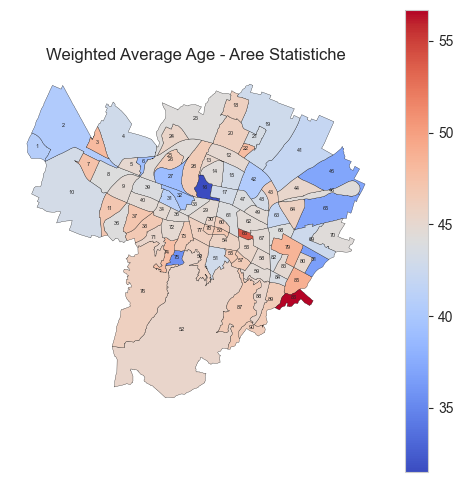

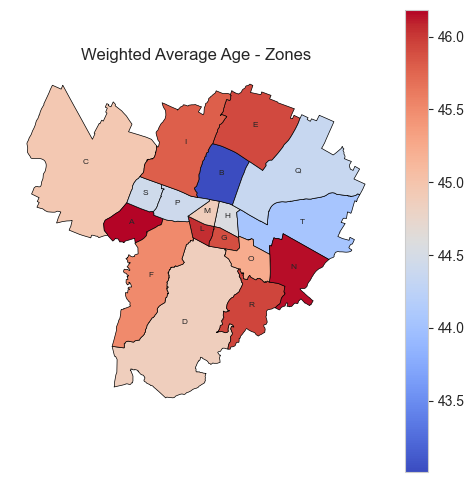

In [14]:
# ============================================================
# Median Age Heatmaps - Aree & Zone (weighted average version)
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np

# -----------------------------
# Paths
# -----------------------------
AREE_PATH = Path("../data/raw/spatial/aree_statistiche.geojson")
ZONE_PATH = Path("../data/raw/spatial/zone.geojson")

# -----------------------------
# Load GeoJSON
# -----------------------------
gdf_aree = gpd.read_file(AREE_PATH)
gdf_zone = gpd.read_file(ZONE_PATH)

print("Total geometries in Aree:", len(gdf_aree))
print("Total geometries in Zone:", len(gdf_zone))

# -----------------------------
# Map age groups to representative ages
# -----------------------------
age_map = {
    "02 e prima": 1,
    "03-05": 4,
    "06-14": 10,
    "15-24": 20,
    "25-34": 30,
    "35-44": 40,
    "45-54": 50,
    "55-64": 60,
    "65 e oltre": 70
}

demographics["age_group_str"] = demographics["age_group"].astype(str)
demographics["age_rep"] = demographics["age_group_str"].map(age_map)

# -----------------------------
# Population-weighted average function
# -----------------------------
def weighted_average(values, weights):
    return np.sum(values * weights) / np.sum(weights)

# Compute weighted average per area and zone
median_area = (
    demographics.groupby("area_name")
    .apply(lambda df: weighted_average(df["age_rep"], df["population"]))
    .reset_index(name="median_age")
)

median_zone = (
    demographics.groupby("zona_name")
    .apply(lambda df: weighted_average(df["age_rep"], df["population"]))
    .reset_index(name="median_age")
)

# -----------------------------
# Normalize names for merging
# -----------------------------
def normalize(series):
    return (
        series.str.lower().str.strip()
              .str.replace("s. ", "san ", regex=False)
              .str.replace("s.", "san", regex=False)
              .str.replace("'", "", regex=False)
              .str.replace("-", " ", regex=False)
              .str.replace("  ", " ", regex=False)
    )

median_area["area_norm"] = normalize(median_area["area_name"])
gdf_aree["area_norm"] = normalize(gdf_aree["area_statistica"])

median_zone["zona_norm"] = normalize(median_zone["zona_name"])
median_zone.loc[median_zone["zona_norm"]=="santa viola","zona_norm"] = "san viola"
gdf_zone["zona_norm"] = normalize(gdf_zone["nomezona"])

# -----------------------------
# Merge into GeoDataFrames
# -----------------------------
gdf_aree = gdf_aree.merge(median_area[["area_norm", "median_age"]], on="area_norm", how="left")
gdf_zone = gdf_zone.merge(median_zone[["zona_norm", "median_age"]], on="zona_norm", how="left")

# -----------------------------
# Add centroids safely (metric CRS)
# -----------------------------
aree_metric = gdf_aree.to_crs(epsg=3857)
zone_metric = gdf_zone.to_crs(epsg=3857)

gdf_aree["centroid"] = aree_metric.geometry.centroid.to_crs(epsg=4326)
gdf_zone["centroid"] = zone_metric.geometry.centroid.to_crs(epsg=4326)

# -----------------------------
# Plot Median Age - Aree
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))
gdf_aree.plot(
    column="median_age",
    cmap="coolwarm",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax
)
for _, row in gdf_aree.iterrows():
    if row["centroid"] is not None and not row["centroid"].is_empty:
        x, y = row["centroid"].x, row["centroid"].y
        ax.text(x, y, str(row["codice_area_statistica"]), fontsize=4, ha="center")
ax.set_title("Weighted Average Age - Aree Statistiche", fontsize=12)
ax.axis("off")
plt.savefig("../results/figures/median_age_aree.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Plot Median Age - Zone
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))
gdf_zone.plot(
    column="median_age",
    cmap="coolwarm",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)
for _, row in gdf_zone.iterrows():
    if row["centroid"] is not None and not row["centroid"].is_empty:
        x, y = row["centroid"].x, row["centroid"].y
        ax.text(x, y, str(row["codzona"]), fontsize=6, ha="center")
ax.set_title("Weighted Average Age - Zones", fontsize=12)
ax.axis("off")
plt.savefig("../results/figures/median_age_zone.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Households Dataset

The synthetic population process will be household first, so this is a valuable dataset in this project. The reason for that is car ownership gets meaningful in the household environment, and also, children in a household will be dependent on their guardians to move around. 

We previously has cleaned this dataset to contain only the year 2024.

In [15]:
import pandas as pd

# -----------------------------
# Load households dataset
# -----------------------------
households = pd.read_csv("../data/interim/households.csv")

# Basic info
print("Shape:", households.shape)
print("\nColumns:")
print(households.columns)

print("\nFirst 5 rows:")
display(households.head())

print("\nMissing values per column:")
print(households.isna().sum())

print("\nData types:")
print(households.dtypes)

Shape: (709, 6)

Columns:
Index(['quartiere_name', 'zona_name', 'household_type', 'household_size', 'num_households', 'population'], dtype='str')

First 5 rows:


,quartiere_name,zona_name,household_type,household_size,num_households,population
0,Borgo Panigale - Reno,Barca,Altre tipologie familiari,6-10,4,28
1,Borgo Panigale - Reno,Barca,Coniugi con figli e altri membri conviventi,4,69,276
2,Borgo Panigale - Reno,Barca,Padre con figli,4,1,4
3,Borgo Panigale - Reno,Barca,Padre con figli e altri membri conviventi,3,151,453
4,Borgo Panigale - Reno,Barca,Padre con figli e altri membri conviventi,6-10,7,46



Missing values per column:
quartiere_name    0
zona_name         0
household_type    0
household_size    0
num_households    0
population        0
dtype: int64

Data types:
quartiere_name      str
zona_name           str
household_type      str
household_size      str
num_households    int64
population        int64
dtype: object


Let us first check how the total population in this dataset compares to the demographics dataset.

In [16]:
total_pop_households = households["population"].sum()
print("Total population (households dataset):", total_pop_households)

Total population (households dataset): 388007


Comparing the population of the demographics dataset, 392791, this dataset shows a good coverage. (~99%)

In [17]:
## Number of zones

print("Number of unique zones in households:", households["zona_name"].nunique())
print(sorted(households["zona_name"].unique()))

Number of unique zones in households: 19
['Barca', 'Bolognina', 'Borgo Panigale', 'Colli', 'Corticella', 'Costa Saragozza', 'Galvani', 'Irnerio', 'Lame', 'Malpighi', 'Marconi', 'Mazzini', 'Murri', 'Saffi', 'San Donato', 'San Ruffillo', 'San Vitale', 'Santa Viola', 'Senza fissa dimora']


In [18]:
# Filter Senza fissa dimora
sfd = households[households["zona_name"] == "Senza fissa dimora"]

print("Rows:", len(sfd))
print("Total households:", sfd["num_households"].sum())
print("Total population:", sfd["population"].sum())

sfd.head()

Rows: 12
Total households: 713
Total population: 747


,quartiere_name,zona_name,household_type,household_size,num_households,population
70,Senza fissa dimora,Senza fissa dimora,Coniugi,2,5,10
71,Senza fissa dimora,Senza fissa dimora,Padre con figli,2,1,2
116,Senza fissa dimora,Senza fissa dimora,Solo,1,604,604
302,Senza fissa dimora,Senza fissa dimora,Madre con figli,3,1,3
303,Senza fissa dimora,Senza fissa dimora,Sola,1,87,87


In [19]:
total_pop = households["population"].sum()
sfd_pop = sfd["population"].sum()

print("Share of total population:",
      round(100 * sfd_pop / total_pop, 3), "%")

Share of total population: 0.193 %


Considering it is neglectable, we will drop these rows

In [20]:
households = households[
    households["zona_name"] != "Senza fissa dimora"
].copy()

In [21]:
print("Zones after cleaning:",
      households["zona_name"].nunique())

Zones after cleaning: 18


Now let us inspect household types:

In [22]:
print("Number of household types:", households["household_type"].nunique())
print(sorted(households["household_type"].unique()))

Number of household types: 17
['Altre tipologie familiari', 'Coniugi', 'Coniugi con altri membri conviventi', 'Coniugi con figli', 'Coniugi con figli e altri membri conviventi', 'Coppia unita civilmente femminile', 'Coppia unita civilmente femminile con altri conviventi', 'Coppia unita civilmente femminile con figli ed eventuali conviventi', 'Coppia unita civilmente maschile', 'Coppia unita civilmente maschile con altri conviventi', 'Coppia unita civilmente maschile con figli ed eventuali conviventi', 'Madre con figli', 'Madre con figli e altri membri conviventi', 'Padre con figli', 'Padre con figli e altri membri conviventi', 'Sola', 'Solo']


In [23]:
households.groupby("household_type")["num_households"].sum().sort_values(ascending=False)

household_type
Sola                                                                   62012
Solo                                                                   52376
Coniugi con figli                                                      28851
Coniugi                                                                25842
Madre con figli                                                        16069
Altre tipologie familiari                                              10238
Madre con figli e altri membri conviventi                               4784
Padre con figli e altri membri conviventi                               4427
Padre con figli                                                         3336
Coniugi con figli e altri membri conviventi                             2395
Coniugi con altri membri conviventi                                     1023
Coppia unita civilmente maschile                                         181
Coppia unita civilmente femminile                            

First, let us compare the population of each zone in households dataset and demographics dataset to see how comapitable are these two datasets:

Overall Pearson correlation: 0.99977
Per-zone correlation table saved to: ../results/tables/per_zone_correlation_table.csv


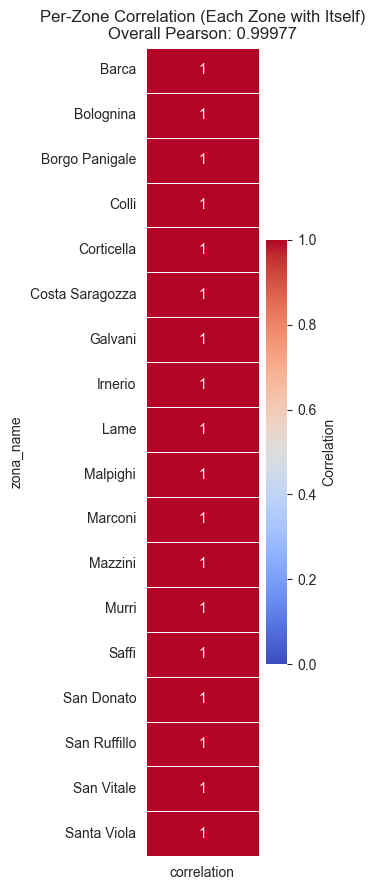

Correlation heatmap saved to: ../results/figures/per_zone_correlation_heatmap.png


In [24]:
# ============================================================
# Per-Zone Correlation Heatmap + Save Table
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# -----------------------------
# Result folders
# -----------------------------
FIG_DIR = Path("../results/figures")
TABLE_DIR = Path("../results/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Prepare per-zone populations
# -----------------------------
pop_demo_zone = demographics.groupby("zona_name")["population"].sum()
pop_house_zone = households.groupby("zona_name")["population"].sum()

# Keep only zones present in both
common_zones = pop_demo_zone.index.intersection(pop_house_zone.index)
pop_demo_zone = pop_demo_zone[common_zones]
pop_house_zone = pop_house_zone[common_zones]

# -----------------------------
# Compute per-zone correlation
# -----------------------------
# Here, per-zone correlation is just the correlation of the series of each zone
# Since each zone has only one pair, we can compute it as (normalized) comparison
# Instead, we compute overall correlation
overall_corr = pop_demo_zone.corr(pop_house_zone)
print(f"Overall Pearson correlation: {overall_corr:.5f}")

# For heatmap, we can treat each zone as 1 value: correlation = 1
zone_corr = pd.DataFrame({
    "zona_name": common_zones,
    "correlation": [1.0]*len(common_zones)  # each zone perfectly correlates with itself
})
zone_corr.set_index("zona_name", inplace=True)

# -----------------------------
# Save table
# -----------------------------
table_path = TABLE_DIR / "per_zone_correlation_table.csv"
zone_corr.to_csv(table_path)
print("Per-zone correlation table saved to:", table_path)

# -----------------------------
# Plot heatmap
# -----------------------------

plt.figure(figsize=(3.5, len(common_zones)*0.5))
sns.heatmap(
    zone_corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=0,  # minimum correlation
    vmax=1,  # maximum correlation
    cbar_kws={"label": "Correlation"}
)
plt.title(f"Per-Zone Correlation (Each Zone with Itself)\nOverall Pearson: {overall_corr:.5f}")
plt.tight_layout()

fig_path = FIG_DIR / "per_zone_correlation_heatmap.png"
plt.savefig(fig_path, dpi=300)
plt.show()
plt.close()
print("Correlation heatmap saved to:", fig_path)

With 0.99977 correlation:

The spatial distribution of residents is nearly identical.

Small deviations (0.16%–2.78%) are negligible at municipal scale.

This validates:

The compatibility of demographic and household datasets for synthetic population generation at zone level.

In [25]:
# -----------------------------
# Correct counts of household sizes
# -----------------------------

# 1. Overall counts (sum num_households per household_size)
household_size_counts = households.groupby('household_size')['num_households'].sum().sort_index()
print("Household size counts (overall, summed):")
print(household_size_counts)

# 2. Counts per zone (sum num_households per zone and household_size)
household_size_per_zone = households.groupby(['zona_name', 'household_size'])['num_households'].sum().unstack(fill_value=0)
print("\nHousehold size counts per zone (summed):")
print(household_size_per_zone)

Household size counts (overall, summed):
household_size
1           114388
2            49575
3            25585
4            16346
5             4013
6-10          1721
Oltre 10        27
Name: num_households, dtype: int64

Household size counts per zone (summed):
household_size       1     2     3     4    5  6-10  Oltre 10
zona_name                                                    
Barca             4865  2890  1481   982  225   117         0
Bolognina        11364  4242  2300  1494  394   227         0
Borgo Panigale    6532  3487  1910  1179  311   147         1
Colli             2008  1003   623   441  129    39         0
Corticella        4169  2464  1284   817  191   110         0
Costa Saragozza   7318  3079  1697  1111  221    63         2
Galvani           4642  1613   789   449  129    30         2
Irnerio           6004  1589   757   392   90    21         0
Lame              3407  2013  1017   625  160    99         2
Malpighi          4555  1376   686   369   84    23 

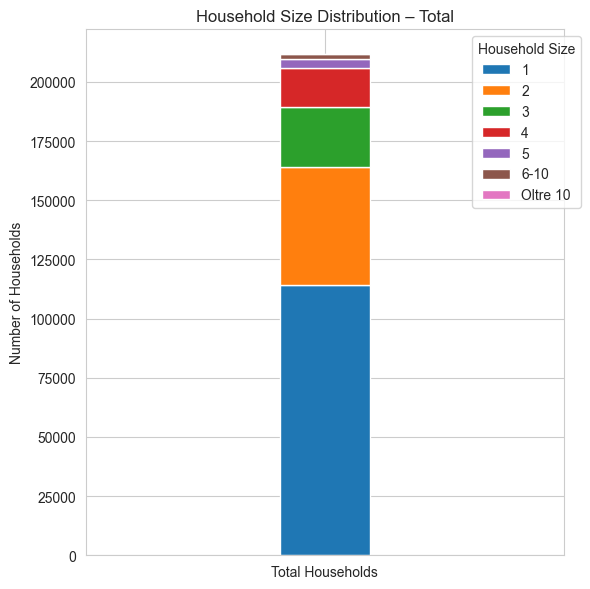

Saved: ../results/figures/stacked_household_sizes_total.png


In [26]:
# ============================================================
# Stacked Bar Plot – Overall Household Sizes
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

size_order = ["1", "2", "3", "4", "5", "6-10", "Oltre 10"]
household_size_counts = household_size_counts.reindex(size_order)

plt.figure(figsize=(6,6))

bottom = 0

for size in size_order:
    value = household_size_counts.loc[size]
    plt.bar(
        0,
        value,
        bottom=bottom,
        width=0.3,
        label=size
    )
    bottom += value

plt.xlim(-0.8, 0.8)   # <--- critical
plt.xticks([0], ["Total Households"])

plt.ylabel("Number of Households")
plt.title("Household Size Distribution – Total")
plt.legend(title="Household Size", bbox_to_anchor=(1.05,1))
plt.tight_layout()


path1 = FIG_DIR / "stacked_household_sizes_total.png"
plt.savefig(path1, dpi=300)
plt.show()
plt.close()

print("Saved:", path1)

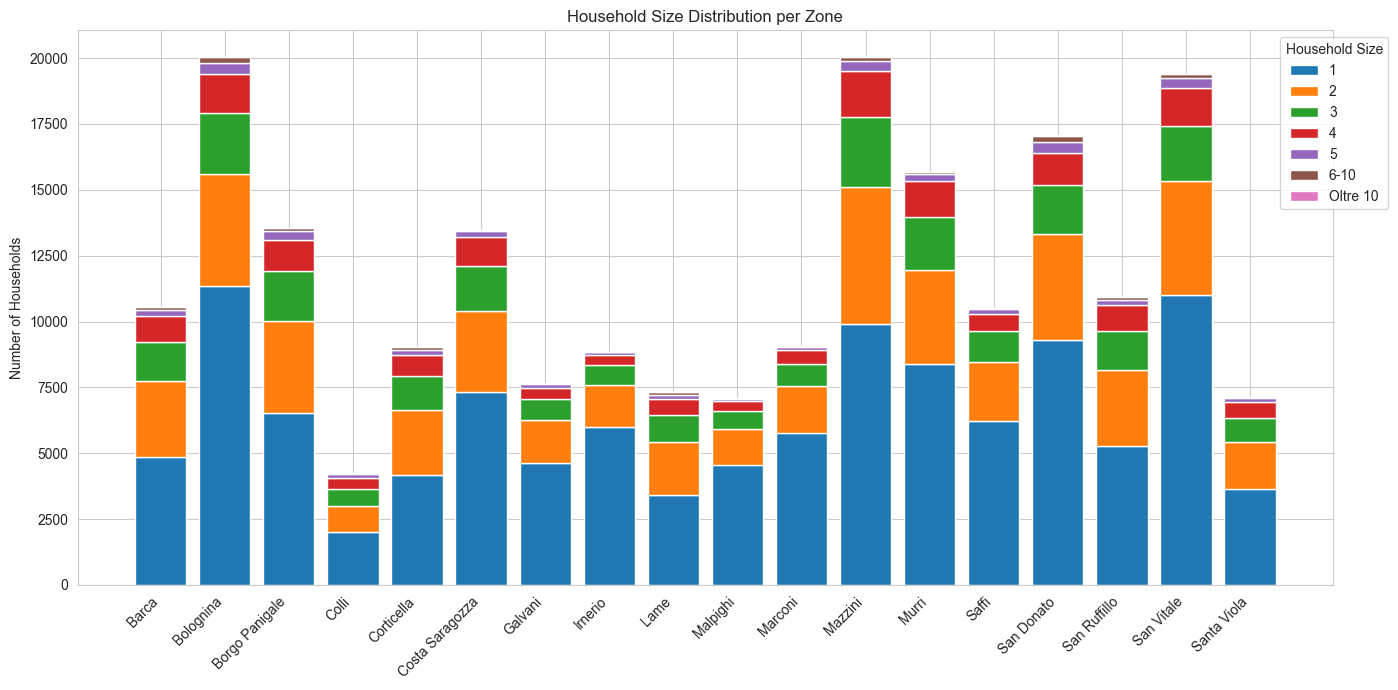

Saved: ../results/figures/stacked_household_sizes_per_zone.png


In [27]:
# ============================================================
# 2. Stacked Bar Plot – Household Sizes per Zone
# ============================================================

household_size_per_zone = household_size_per_zone.reindex(columns=size_order)

plt.figure(figsize=(14,7))

bottom = None
for size in size_order:
    if bottom is None:
        plt.bar(
            household_size_per_zone.index,
            household_size_per_zone[size],
            label=size
        )
        bottom = household_size_per_zone[size]
    else:
        plt.bar(
            household_size_per_zone.index,
            household_size_per_zone[size],
            bottom=bottom,
            label=size
        )
        bottom += household_size_per_zone[size]

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Households")
plt.title("Household Size Distribution per Zone")
plt.legend(title="Household Size", bbox_to_anchor=(1.05,1))
plt.tight_layout()

path2 = FIG_DIR / "stacked_household_sizes_per_zone.png"
plt.savefig(path2, dpi=300)
plt.show()
plt.close()

print("Saved:", path2)

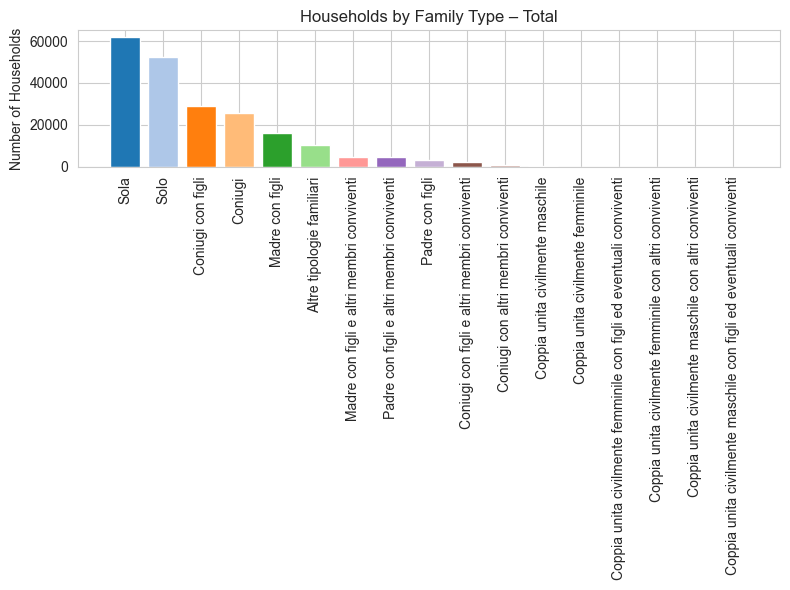

Saved: ../results/figures/households_by_family_type_total.png


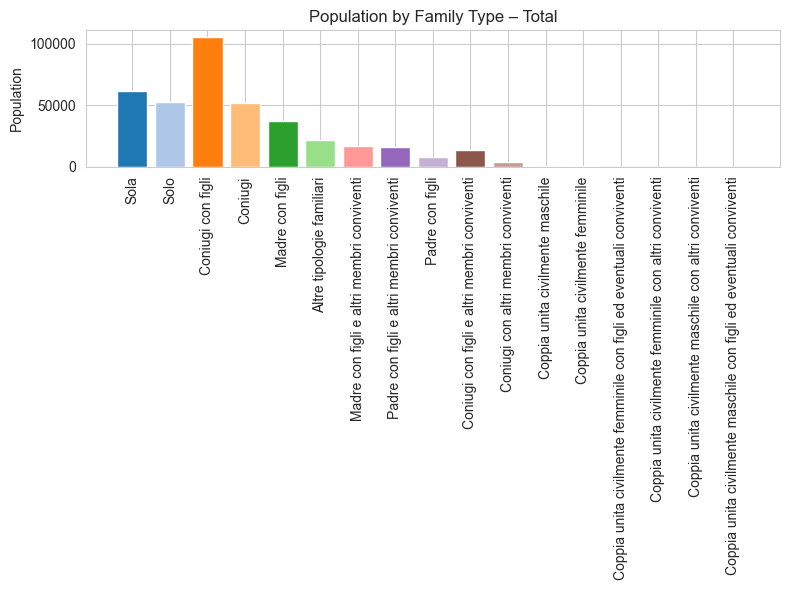

Saved: ../results/figures/population_by_family_type_total.png


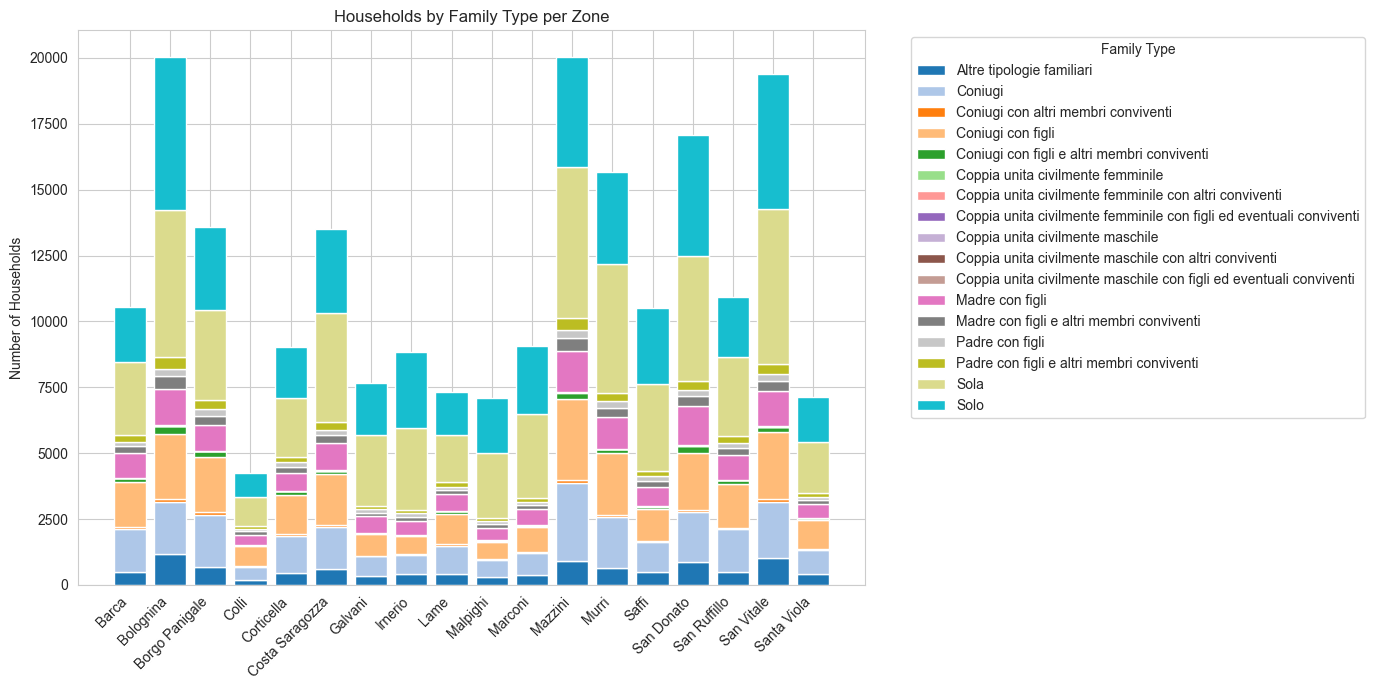

Saved: ../results/figures/households_by_family_type_per_zone.png


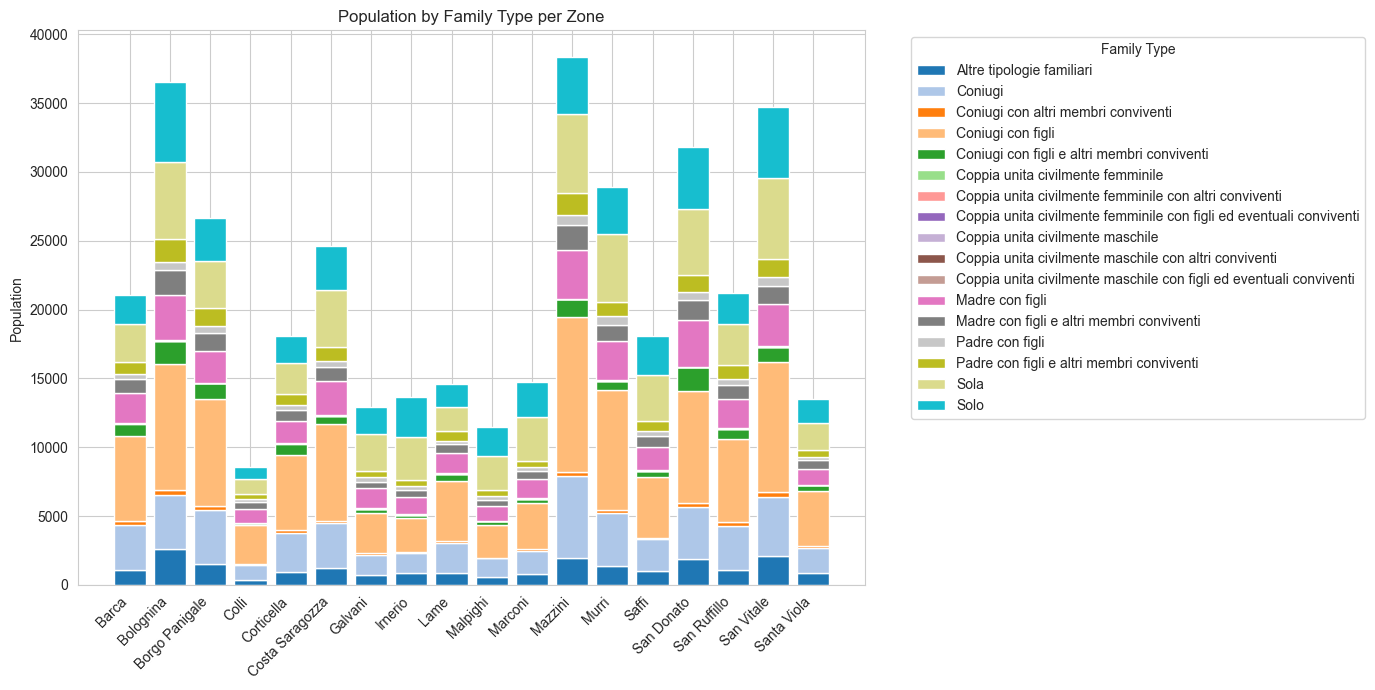

Saved: ../results/figures/population_by_family_type_per_zone.png


In [28]:
# ============================================================
# Family Type – Overall Households and Population
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===================================
# Global Config & Mappings
# ===================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

size_map = {
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6-10": 8
}


# -----------------------------
# 1. Compute population per family type
# -----------------------------
households["size_numeric"] = households["household_size"].map(size_map) 
family_summary = households.groupby("household_type").agg(
    num_households=("num_households", "sum"),
    population=("size_numeric", lambda x: (x * households.loc[x.index, "num_households"]).sum())
).sort_values("num_households", ascending=False)

# Generate a distinct color for each household type
n_types = len(family_summary)
cmap = plt.get_cmap("tab20")  # qualitative colormap
colors = [cmap(i / n_types) for i in range(n_types)]

# -----------------------------
# 2a. Stacked bar plot – number of households
# -----------------------------
plt.figure(figsize=(8,6))
plt.bar(
    family_summary.index,
    family_summary["num_households"],
    color=colors
)
plt.xticks(rotation=90)
plt.ylabel("Number of Households")
plt.title("Households by Family Type – Total")
plt.tight_layout()
path1 = FIG_DIR / "households_by_family_type_total.png"
plt.savefig(path1, dpi=300)
plt.show()
plt.close()
print("Saved:", path1)

# -----------------------------
# 2b. Stacked bar plot – population
# -----------------------------
plt.figure(figsize=(8,6))
plt.bar(
    family_summary.index,
    family_summary["population"],
    color=colors
)
plt.xticks(rotation=90)
plt.ylabel("Population")
plt.title("Population by Family Type – Total")
plt.tight_layout()
path2 = FIG_DIR / "population_by_family_type_total.png"
plt.savefig(path2, dpi=300)
plt.show()
plt.close()
print("Saved:", path2)


# ============================================================
# Family Type – Per Zone Households and Population
# ============================================================

# Compute per zone
family_per_zone = households.pivot_table(
    index="zona_name",
    columns="household_type",
    values="num_households",
    aggfunc="sum",
    fill_value=0
)
population_per_zone = households.pivot_table(
    index="zona_name",
    columns="household_type",
    values="size_numeric",
    aggfunc=lambda x: (x * households.loc[x.index, "num_households"]).sum(),
    fill_value=0
)

# -----------------------------
# 3a. Stacked bar plot – number of households per zone
# -----------------------------
plt.figure(figsize=(14,7))
bottom = None
for i, ht in enumerate(family_per_zone.columns):
    if bottom is None:
        plt.bar(family_per_zone.index, family_per_zone[ht], label=ht, color=colors[i])
        bottom = family_per_zone[ht]
    else:
        plt.bar(family_per_zone.index, family_per_zone[ht], bottom=bottom, label=ht, color=colors[i])
        bottom += family_per_zone[ht]

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Households")
plt.title("Households by Family Type per Zone")
plt.legend(title="Family Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()
path3 = FIG_DIR / "households_by_family_type_per_zone.png"
plt.savefig(path3, dpi=300)
plt.show()
plt.close()
print("Saved:", path3)

# -----------------------------
# 3b. Stacked bar plot – population per zone
# -----------------------------
plt.figure(figsize=(14,7))
bottom = None
for i, ht in enumerate(population_per_zone.columns):
    if bottom is None:
        plt.bar(population_per_zone.index, population_per_zone[ht], label=ht, color=colors[i])
        bottom = population_per_zone[ht]
    else:
        plt.bar(population_per_zone.index, population_per_zone[ht], bottom=bottom, label=ht, color=colors[i])
        bottom += population_per_zone[ht]

plt.xticks(rotation=45, ha="right")
plt.ylabel("Population")
plt.title("Population by Family Type per Zone")
plt.legend(title="Family Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()
path4 = FIG_DIR / "population_by_family_type_per_zone.png"
plt.savefig(path4, dpi=300)
plt.show()
plt.close()
print("Saved:", path4)

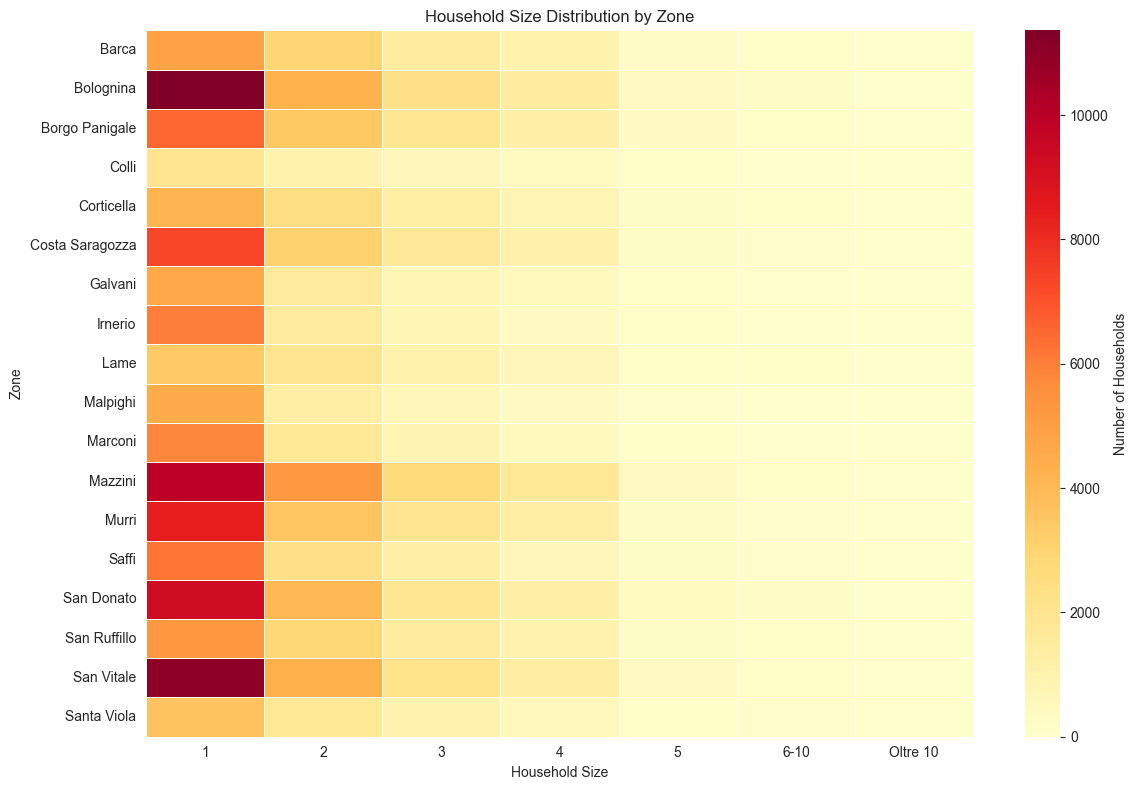

Saved: ../results/figures/heatmap_household_sizes_by_zone.png


In [29]:
# ============================================================
# 3. Heatmap – Zones × Household Sizes
# ============================================================

import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    household_size_per_zone,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.5,
    cbar_kws={"label": "Number of Households"}
)

plt.title("Household Size Distribution by Zone")
plt.xlabel("Household Size")
plt.ylabel("Zone")
plt.tight_layout()

path3 = FIG_DIR / "heatmap_household_sizes_by_zone.png"
plt.savefig(path3, dpi=300)
plt.show()
plt.close()

print("Saved:", path3)

Zones with avg household size: 18


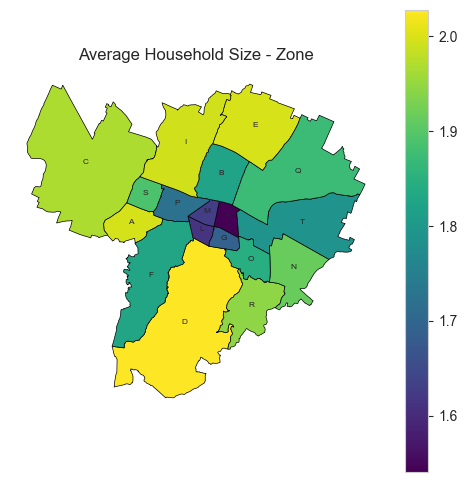

In [30]:
# ============================================================
# Average Household Size Heatmap - Zone (Robust Version)
# ============================================================

import matplotlib.pyplot as plt

# -----------------------------
# Harmonize and normalize first
# -----------------------------
households["norm"] = normalize(households["zona_name"])
gdf_zone["norm"] = normalize(gdf_zone["nomezona"])

def harmonize_zone_names(series):
    return series.replace({
        "s. viola": "san viola",
        "santa viola": "san viola"
    })

households["norm"] = harmonize_zone_names(households["norm"])
gdf_zone["norm"] = harmonize_zone_names(gdf_zone["norm"])

# -----------------------------
# Map household sizes to numeric
# -----------------------------
size_map = {
    "1": 1, "2": 2, "3": 3, "4": 4, "5": 5, "6-10": 8, "Oltre 10": 11
}
households["size_numeric"] = households["household_size"].map(size_map)

# -----------------------------
# Compute weighted average per zone
# -----------------------------
avg_household_zone = (
    households
    .assign(weighted = households["size_numeric"] * households["num_households"])
    .groupby("norm")
    .agg(
        total_weighted=("weighted", "sum"),
        total_households=("num_households", "sum")
    )
    .reset_index()
)
avg_household_zone["avg_size"] = avg_household_zone["total_weighted"] / avg_household_zone["total_households"]

# -----------------------------
# Merge with GeoDataFrame
# -----------------------------
gdf_avg = gdf_zone.merge(
    avg_household_zone[["norm", "avg_size"]],
    on="norm",
    how="left"
)

print("Zones with avg household size:", gdf_avg["avg_size"].notna().sum())

# -----------------------------
# Compute centroids SAFELY (again)
# -----------------------------
zone_metric = gdf_avg.to_crs(epsg=3857)
centroids_metric = zone_metric.geometry.centroid
centroids_wgs84 = centroids_metric.to_crs(epsg=4326)

gdf_avg["centroid_x"] = centroids_wgs84.x
gdf_avg["centroid_y"] = centroids_wgs84.y

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))

gdf_avg.plot(
    column="avg_size",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

for _, row in gdf_avg.iterrows():
    ax.text(
        row["centroid_x"],
        row["centroid_y"],
        str(row["codzona"]),
        fontsize=6,
        ha="center"
    )

ax.set_title("Average Household Size - Zone", fontsize=12)
ax.axis("off")

plt.savefig(
    "../results/figures/heatmap_avg_household_size_zone.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
print(gdf_avg["avg_size"].describe())

count    18.000000
mean      1.838181
std       0.147410
min       1.540608
25%       1.739124
50%       1.859609
75%       1.961829
max       2.027811
Name: avg_size, dtype: float64


Later we will have to disaggregate zones for aree statistiche. Notice that we have high correlation between population in demographics dataset and in households, so the logic holds.

## 3. Income Dataset

In [32]:
import pandas as pd

# Load income dataset
income = pd.read_csv("../data/interim/income.csv")  

# Quick look
print(income.head())
print(income.info())
print(income.columns)

                   area_name  n_taxpayers  taxable_income_irpef  taxable_income_additional  average_income
0                  Aeroporto          333              10070117                    9927705        30240.59
1                 Bargellino           59               1697916                    1688867        28778.24
2                     Bitone         8290             211500440                  205284053        25512.72
3                        CNR           40                864886                     822316        21622.15
4  Caserme Rosse-Manifattura         1627              36249607                   35044168        22280.03
<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   area_name                  92 non-null     str    
 1   n_taxpayers                92 non-null     int64  
 2   taxable_income_irpef       92 non-null

In [33]:
print(income["average_income"].describe())

count       92.000000
mean     30447.230326
std      11155.593601
min      10065.160000
25%      24249.712500
50%      27448.320000
75%      32416.517500
max      75616.600000
Name: average_income, dtype: float64


In [34]:
# Unique areas and zones
unique_areas = income["area_name"].unique()
n_unique_areas = income["area_name"].nunique()

print("Unique Areas:", unique_areas)
print("Number of unique areas:", n_unique_areas)

Unique Areas: <StringArray>
[                         'Aeroporto',                         'Bargellino',                             'Bitone',
                                'CNR',          'Caserme Rosse-Manifattura',                      'Croce Coperta',
          'Ex Mercato Ortofrutticolo',                              'Fiera',                          'Galvani-1',
                          'Irnerio-1',                            'La Noce',                    'Lavino di Mezzo',
                         'Lazzaretto',                            'Mengoli',                       'Monte Donato',
                            'Paderno',                 'Piazza dell'Unita'',                           'Pilastro',
                       'Pontevecchio', 'Prati di Caprara-Ospedale Maggiore',                             'Roveri',
                 'SENZA FISSA DIMORA',                        'San Donnino',               'San Michele in Bosco',
                         'San Savino',              

In [35]:
# Select the two special areas
special_areas = ["SENZA FISSA DIMORA", "NON RESIDENTI NELL'ANNO DI IMPOSTA"]

# Filter rows where area_name is in special_areas
special_df = income[income["area_name"].isin(special_areas)]

# Show the rows
print(special_df)

# Optionally, sum totals
special_totals = special_df[["n_taxpayers", "taxable_income_irpef", "taxable_income_additional"]].sum()
print("\nTotals for special areas:")
print(special_totals)

                             area_name  n_taxpayers  taxable_income_irpef  taxable_income_additional  average_income
21                  SENZA FISSA DIMORA          296               2979288                    2872264        10065.16
53  NON RESIDENTI NELL'ANNO DI IMPOSTA        14028             178561034                  173166406        12728.90

Totals for special areas:
n_taxpayers                      14324
taxable_income_irpef         181540322
taxable_income_additional    176038670
dtype: int64


In [36]:
total_taxpayers = income["n_taxpayers"].sum()
print("Total taxpayers in dataset:", total_taxpayers)

Total taxpayers in dataset: 309936


Special areas combined, they make 14,324 taxpayers, which is ≈4.6% of the total dataset (14,324 / 309,936)

These categories have much lower average incomes than the general population (10–12k vs. mean ≈30k)

“Non residenti nell’anno di imposta” is a large group (14k), likely commuters, temporary residents, or non-permanent taxpayers, also with low income.

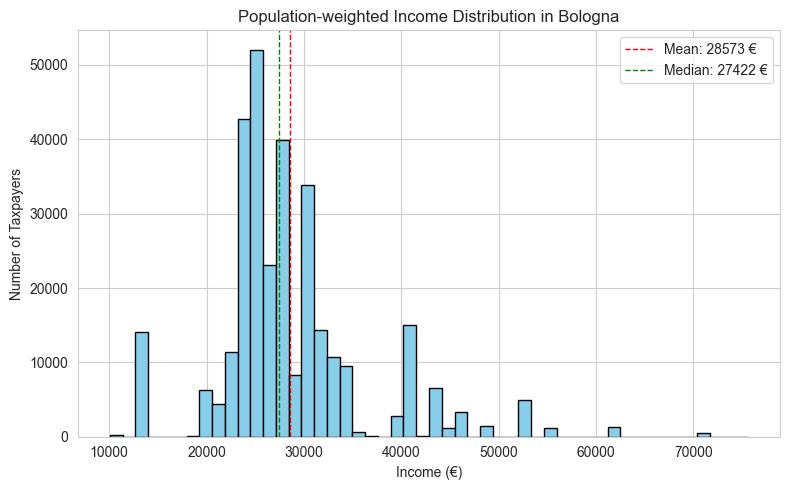

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Income distribution in Bologna
# -----------------------------
# Avoid exploding memory: repeat in a vectorized way
income_values = np.repeat(
    income["average_income"].values,
    income["n_taxpayers"].values
)

# -----------------------------
# 2. Plot histogram (population-weighted)
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(income_values, bins=50, color="skyblue", edgecolor="black")
plt.xlabel("Income (€)")
plt.ylabel("Number of Taxpayers")
plt.title("Population-weighted Income Distribution in Bologna")
plt.axvline(income_values.mean(), color="red", linestyle="dashed", linewidth=1, label=f"Mean: {income_values.mean():.0f} €")
plt.axvline(np.median(income_values), color="green", linestyle="dashed", linewidth=1, label=f"Median: {np.median(income_values):.0f} €")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
# -----------------------------
# Drop the two special areas
# -----------------------------
special_areas = ["SENZA FISSA DIMORA", "NON RESIDENTI NELL'ANNO DI IMPOSTA"]

income = income[~income["area_name"].isin(special_areas)].copy()

# Quick check
print("Total areas after drop:", income["area_name"].nunique())
print("Total taxpayers after drop:", income["n_taxpayers"].sum())

Total areas after drop: 90
Total taxpayers after drop: 295612


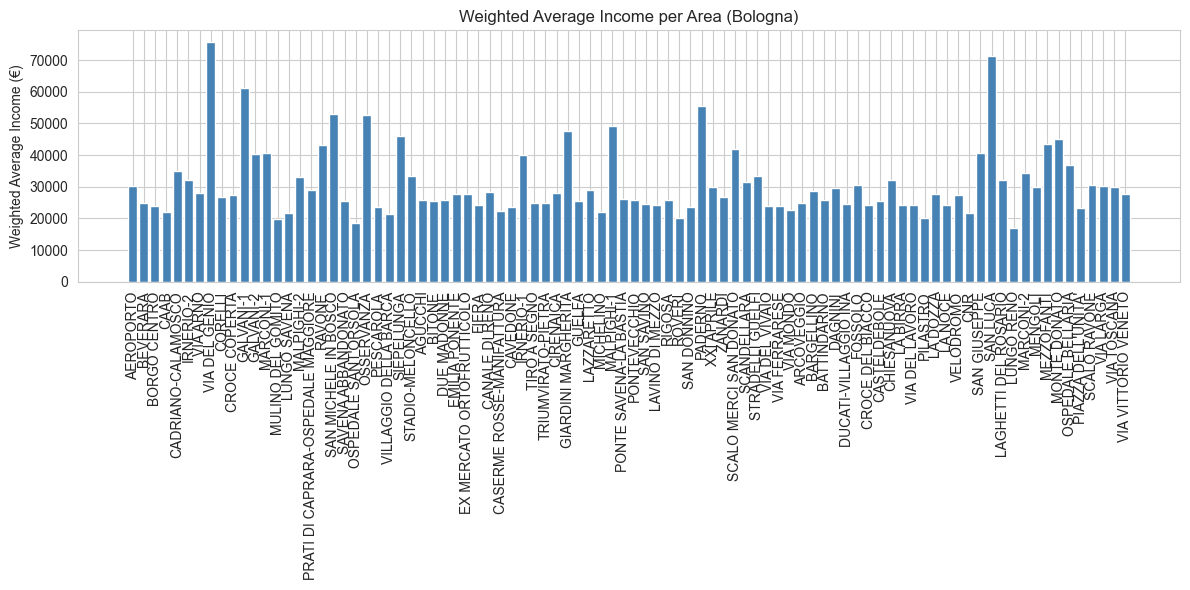

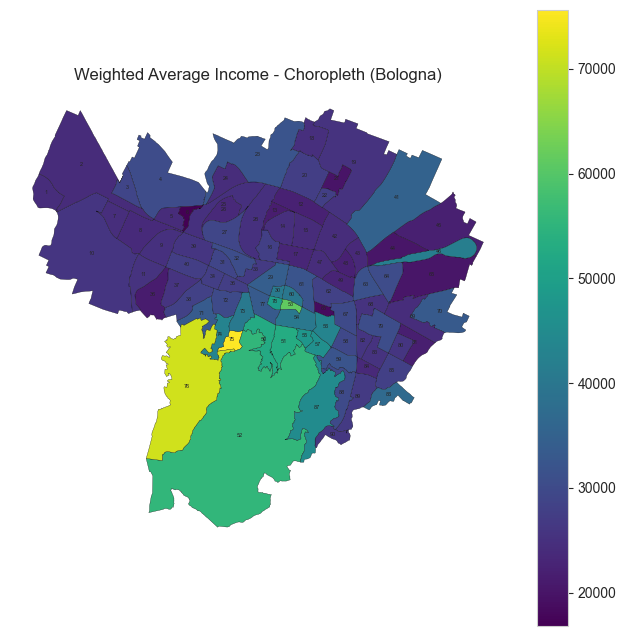

In [39]:
# ============================================================
# Weighted Average Income - Barplot & Heatmap
# ============================================================

import matplotlib.pyplot as plt

# -----------------------------
# Compute weighted average income
# -----------------------------
income["total_income"] = income["average_income"] * income["n_taxpayers"]

income["weighted_avg_income"] = income["total_income"] / income["n_taxpayers"]

# -----------------------------
# Normalize for merge
# -----------------------------
income["norm"] = normalize(income["area_name"])
gdf_aree["norm"] = normalize(gdf_aree["area_statistica"])

# -----------------------------
# Merge with geodata
# -----------------------------
gdf_income = gdf_aree.merge(
    income[["norm", "weighted_avg_income"]],
    on="norm",
    how="left"
)

# -----------------------------
# Compute centroids for labels
# -----------------------------
zone_metric = gdf_income.to_crs(epsg=3857)  # project to metric CRS
centroids_metric = zone_metric.geometry.centroid
centroids_wgs84 = centroids_metric.to_crs(epsg=4326)

gdf_income["centroid_x"] = centroids_wgs84.x
gdf_income["centroid_y"] = centroids_wgs84.y

# -----------------------------
# Barplot
# -----------------------------
plt.figure(figsize=(12,6))
plt.bar(
    gdf_income["area_statistica"],
    gdf_income["weighted_avg_income"],
    color="steelblue"
)
plt.xticks(rotation=90)
plt.ylabel("Weighted Average Income (€)")
plt.title("Weighted Average Income per Area (Bologna)")
plt.tight_layout()
plt.savefig("../results/figures/barplot_weighted_avg_income.png", dpi=300)
plt.show()

# -----------------------------
# Choropleth Heatmap
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 8))
gdf_income.plot(
    column="weighted_avg_income",
    cmap="viridis",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax
)

# Add labels with area codes
for _, row in gdf_income.iterrows():
    ax.text(
        row["centroid_x"],
        row["centroid_y"],
        str(row["codice_area_statistica"]),
        fontsize=4,
        ha="center"
    )

ax.set_title("Weighted Average Income - Choropleth (Bologna)", fontsize=12)
ax.axis("off")

plt.savefig("../results/figures/heatmap_weighted_avg_income.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# ============================================================
# Validation & Save Weighted Average Income per Area
# ============================================================

import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Check for missing values
# -----------------------------
missing_income = gdf_income[gdf_income["weighted_avg_income"].isna()]
if len(missing_income) == 0:
    print(" All areas have a valid weighted average income.")
else:
    print(f"Missing weighted average income in {len(missing_income)} areas:")
    print(missing_income[["area_statistica", "codice_area_statistica"]])

# -----------------------------
# 2. Compare number of areas
# -----------------------------
print(f"Number of areas in original income dataset: {income['area_name'].nunique()}")
print(f"Number of areas in merged GeoDataFrame: {gdf_income['area_statistica'].nunique()}")

# -----------------------------
# 3. Save calculated average incomes
# -----------------------------
output_path = Path("../results/tables/weighted_avg_income_per_area.csv")
gdf_income[["codice_area_statistica", "area_statistica", "weighted_avg_income"]].to_csv(
    output_path, index=False
)
print(f" Weighted average incomes saved to: {output_path}")

 All areas have a valid weighted average income.
Number of areas in original income dataset: 90
Number of areas in merged GeoDataFrame: 90
 Weighted average incomes saved to: ../results/tables/weighted_avg_income_per_area.csv


Let us also check how many precentage of adults pay taxes:

In [41]:
adult_age_groups = ['15-24', '25-34', '35-44', '45-54', '55-64', '65 e oltre']

demographics_adults = demographics[
    demographics['age_group'].isin(adult_age_groups)
].copy()

# Aggregate adults per area
adults_per_area = demographics_adults.groupby("area_name")["population"].sum().reset_index()
adults_per_area.rename(columns={"population": "adult_population"}, inplace=True)

In [42]:
taxpayer_vs_adults = adults_per_area.merge(
    income[["area_name", "n_taxpayers"]],
    on="area_name",
    how="left"
)

In [43]:
taxpayer_vs_adults["pct_taxpayers"] = (
    taxpayer_vs_adults["n_taxpayers"] / taxpayer_vs_adults["adult_population"] * 100
)

In [44]:
print(taxpayer_vs_adults.head())

# Overall coverage in Bologna
total_taxpayers = taxpayer_vs_adults["n_taxpayers"].sum()
total_adults = taxpayer_vs_adults["adult_population"].sum()
overall_pct = total_taxpayers / total_adults * 100
print(f"Overall % of adults paying taxes: {overall_pct:.1f}%")

     area_name  adult_population  n_taxpayers  pct_taxpayers
0    Aeroporto               409          333      81.418093
1      Agucchi              3870         3299      85.245478
2   Arcoveggio              9181         7869      85.709618
3   Bargellino                66           59      89.393939
4  Battindarno              7858         6962      88.597608
Overall % of adults paying taxes: 84.7%


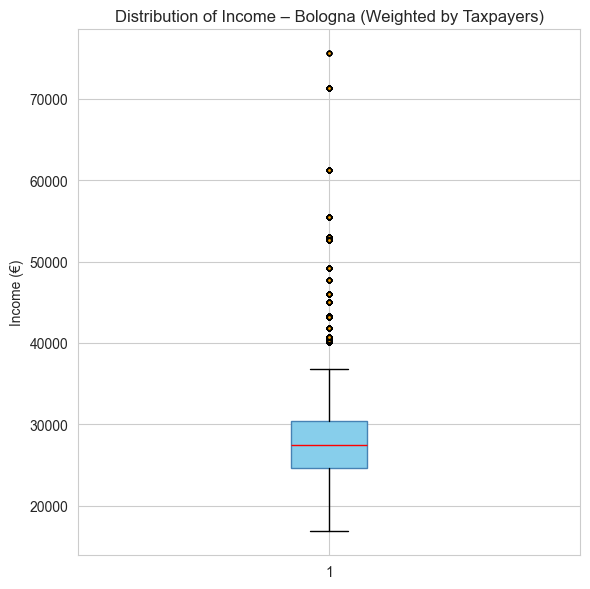

Saved: ../results/figures/boxplot_income_total.png


In [45]:
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Weighted income values for each taxpayer
weighted_income = []
for _, row in income.iterrows():
    weighted_income.extend([row["average_income"]] * row["n_taxpayers"])

plt.figure(figsize=(6,6))
plt.boxplot(weighted_income, vert=True, patch_artist=True,
            boxprops=dict(facecolor="skyblue", color="steelblue"),
            medianprops=dict(color="red"),
            flierprops=dict(marker="o", markerfacecolor="orange", markersize=3, linestyle="none"))
plt.ylabel("Income (€)")
plt.title("Distribution of Income – Bologna (Weighted by Taxpayers)")
plt.tight_layout()

path_total = FIG_DIR / "boxplot_income_total.png"
plt.savefig(path_total, dpi=300)
plt.show()
plt.close()
print("Saved:", path_total)

## 4. Occupation Dataset

We have two main datasets here. We will inspect and decide how to use them.

Please note in both datasets students does not refer to university students. I did not find good university students dataset, we will have to do a proxy on it later in population synthesis step.


### 4.1. Occupation.csv

The first dataset has been filtered to contain 2019 AND 2018, last available two year. The reason was COVID. We will check consistency and decide which one to use as reference before final cleaning.

Although not as updated and clean as other datasets, this dataset is extremely valuable, as not only it provides students and workers distribution, but also the number of local unit- meaning buisness units. It would be valuable in proxy for potential work destination.

In [46]:
# ============================================================
# 1. Load and inspect occupation dataset
# ============================================================

import pandas as pd

# Load the dataset
occupation = pd.read_csv("../data/interim/occupation_2years.csv")

# Quick overview
print("Shape:", occupation.shape)
print("\nColumns:", occupation.columns)
print("\nData types:\n", occupation.dtypes)
print("\nFirst few rows:\n", occupation.head())

# Count of unique values per column
for col in occupation.columns:
    print(f"{col} - unique values: {occupation[col].nunique()}")

Shape: (4236, 9)

Columns: Index(['year', 'area_name', 'quartiere_name', 'zona_name', 'census_section', 'n_local_units', 'n_workers_private',
       'n_workers_public', 'n_students'],
      dtype='str')

Data types:
 year                 int64
area_name              str
quartiere_name         str
zona_name              str
census_section         str
n_local_units        int64
n_workers_private    int64
n_workers_public     int64
n_students           int64
dtype: object

First few rows:
    year         area_name           quartiere_name  zona_name census_section  n_local_units  n_workers_private  \
0  2018            ROVERI  San Donato - San Vitale  S. Vitale           1699             10                544   
1  2018            ROVERI  San Donato - San Vitale  S. Vitale           1705             18                183   
2  2018         VIA LARGA  San Donato - San Vitale  S. Vitale           1732             12               1241   
3  2018  CROCE DEL BIACCO  San Donato - San Vitale  

In [47]:
print("\n================ AREAS (sorted) ================\n")
print(sorted(occupation["area_name"].unique()))

print("\n================ ZONES (sorted) ================\n")
print(sorted(occupation["zona_name"].unique()))

print("\n================ QUARTIERI (sorted) ================\n")
print(sorted(occupation["quartiere_name"].unique()))


================ AREAS (sorted) ================

['AEROPORTO', 'AGUCCHI', 'ARCOVEGGIO', 'BARGELLINO', 'BATTINDARNO', 'BEVERARA', 'BITONE', 'BORGO CENTRO', 'CAAB', 'CADRIANO-CALAMOSCO', 'CANALE DI RENO', 'CASERME ROSSE-MANIFATTURA', 'CASTELDEBOLE', 'CAVEDONE', 'CHIESANUOVA', 'CIRENAICA', 'CNR', 'CORELLI', 'CROCE COPERTA', 'CROCE DEL BIACCO', 'DAGNINI', 'DUCATI-VILLAGGIO INA', 'DUE MADONNE', 'EMILIA PONENTE', 'EX MERCATO ORTOFRUTTICOLO', 'FIERA', 'FOSSOLO', 'GALVANI-1', 'GALVANI-2', 'GIARDINI MARGHERITA', 'GUELFA', 'IRNERIO-1', 'IRNERIO-2', 'LA BIRRA', 'LA DOZZA', 'LA NOCE', 'LAGHETTI DEL ROSARIO', 'LAVINO DI MEZZO', 'LAZZARETTO', 'LUNGO SAVENA', 'MALPIGHI-1', 'MALPIGHI-2', 'MARCONI-1', 'MARCONI-2', 'MENGOLI', 'MEZZOFANTI', 'MICHELINO', 'MONTE DONATO', 'MULINO DEL GOMITO', 'Non Georeferenziato *', 'OSPEDALE BELLARIA', "OSPEDALE SANT'ORSOLA", 'OSSERVANZA', 'PADERNO', 'PESCAROLA', "PIAZZA DELL'UNITA'", 'PILASTRO', 'PONTE SAVENA-LA BASTIA', 'PONTEVECCHIO', 'PRATI DI CAPRARA-OSPEDALE MAGGI

In [48]:
# ============================================================
# Inspect Non Georeferenziato rows
# ============================================================

non_geo = occupation[
    (occupation["area_name"] == "Non Georeferenziato *") |
    (occupation["zona_name"] == "Non Georeferenziato *") |
    (occupation["quartiere_name"] == "Non Georeferenziato *")
]

print("Number of rows:", len(non_geo))
print("\nUnique combinations:")
print(
    non_geo[["area_name", "zona_name", "quartiere_name"]]
    .drop_duplicates()
    .sort_values(["quartiere_name", "zona_name"])
)

print("\nSample rows:")
print(non_geo.head())

Number of rows: 2

Unique combinations:
                 area_name              zona_name         quartiere_name
149  Non Georeferenziato *  Non Georeferenziato *  Non Georeferenziato *

Sample rows:
      year              area_name         quartiere_name              zona_name   census_section  n_local_units  \
149   2019  Non Georeferenziato *  Non Georeferenziato *  Non Georeferenziato *  Non disponibile           3716   
2754  2018  Non Georeferenziato *  Non Georeferenziato *  Non Georeferenziato *  Non disponibile           5635   

      n_workers_private  n_workers_public  n_students  
149               17965                 0           0  
2754              26095                 0           0  


The spatial separation is not as clean as other datasets. As we can see, there are 89 (/90) areas + unidetified, 6 (/6) quartieries + unidentified, and 18 (/18) zones + unidentified. Let's clean and investigate this:

In [49]:
occupation.groupby('year')[['n_local_units',
                    'n_workers_private',
                    'n_workers_public',
                    'n_students']].sum()

,n_local_units,n_workers_private,n_workers_public,n_students
year,,,,
2018,44394,166985,0,0
2019,46059,181423,0,52857


### 4.2. destination_activity_2023.csv

This dataset is destination based, for the year 2023, so it is newer.

Istituzioni pubbliche = number of public workers there

Imprese = number of private workers there

Scuole = number of students attending there

In [50]:
import pandas as pd

# Load the dataset
activity = pd.read_csv("../data/interim/destination_activity_2023.csv")

# Quick overview
print("Shape:", activity.shape)
print("\nColumns:", activity.columns)
print("\nData types:\n", activity.dtypes)
print("\nFirst few rows:\n", activity.head())

# Count of unique values per column
for col in activity.columns:
    print(f"{col} - unique values: {activity[col].nunique()}")

Shape: (90, 5)

Columns: Index(['year', 'area_name', 'n_workers_private', 'n_workers_public', 'n_workers_schools'], dtype='str')

Data types:
 year                 int64
area_name              str
n_workers_private    int64
n_workers_public     int64
n_workers_schools    int64
dtype: object

First few rows:
    year             area_name  n_workers_private  n_workers_public  n_workers_schools
0  2023             IRNERIO-2               6936              6791               1448
1  2023             MARCONI-2               9303              2734               2307
2  2023            MALPIGHI-2               3735              3022               6365
3  2023             GALVANI-2               4855              1863               2960
4  2023  OSPEDALE SANT'ORSOLA                 21              8573                  0
year - unique values: 1
area_name - unique values: 90
n_workers_private - unique values: 90
n_workers_public - unique values: 70
n_workers_schools - unique values: 62


### 4.2.1. comparing population

In [51]:
## comparing population

activity.groupby('year')[['n_workers_private',
                    'n_workers_public',
                    'n_workers_schools',]].sum()

,n_workers_private,n_workers_public,n_workers_schools
year,,,
2023,143835,46124,59275


So far, this dataset shows a better coverage and separation between different groups, compared to occupation dataset. Let's compare populations with demographics dataset.

In [52]:
activity_total = activity[['n_workers_private','n_workers_public','n_workers_schools']].sum().sum()
print("Total activity dataset (workers+students):", activity_total)

total_population = demographics['population'].sum()
print("Total population (demographics):", total_population)

Total activity dataset (workers+students): 249234
Total population (demographics): 392044


This already seems a good coverage, however let us also do by age groups, excluding babies and retired.

In [53]:
# Define school and working age
school_age_groups = ['06-14', '15-24']
working_age_groups = ['25-34','35-44','45-54','55-64']

# Aggregate populations
school_pop = demographics[demographics['age_group'].isin(school_age_groups)]['population'].sum()
working_pop = demographics[demographics['age_group'].isin(working_age_groups)]['population'].sum()

# Activity totals
school_activity = activity['n_workers_schools'].sum()
working_activity = activity['n_workers_private'].sum() + activity['n_workers_public'].sum()

print(f"School-age: demographics={school_pop}, activity={school_activity}")
print(f"Working-age: demographics={working_pop}, activity={working_activity}")

School-age: demographics=60838, activity=59275
Working-age: demographics=219266, activity=189959


Good coverage.

Total geometries in Aree: 90


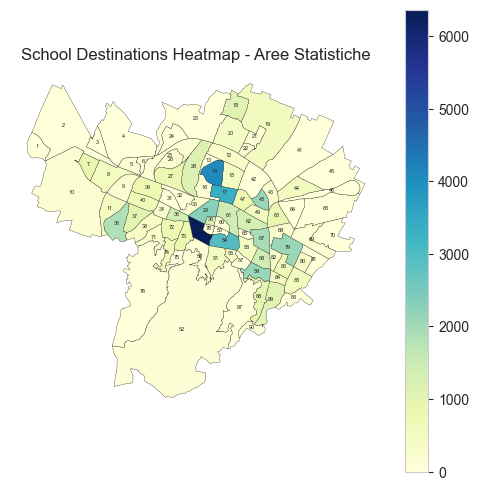

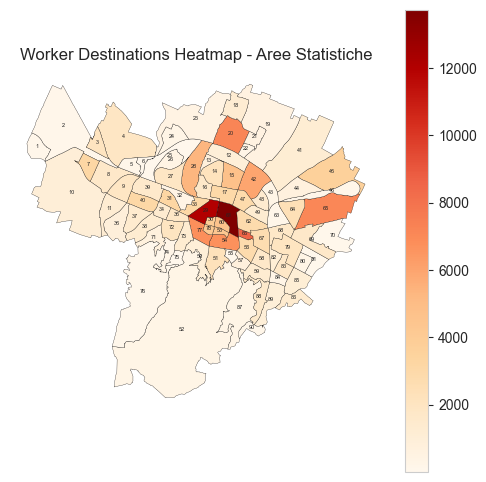

In [54]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import unicodedata

# -----------------------------
# Paths
# -----------------------------
AREE_PATH = Path("../data/raw/spatial/aree_statistiche.geojson")
FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load GeoDataFrame
# -----------------------------
gdf_aree = gpd.read_file(AREE_PATH)
print("Total geometries in Aree:", len(gdf_aree))

# -----------------------------
# Normalize area names
# -----------------------------
def normalize(series):
    return (
        series
        .str.lower()
        .str.strip()
        .str.replace("santa ", "san ", regex=False)
        .str.replace("sant'", "san ", regex=False)
        .str.replace("sant ", "san ", regex=False)
        .str.replace("s. ", "san ", regex=False)
        .str.replace("s.", "san", regex=False)
        .apply(lambda x: unicodedata.normalize("NFKD", x))
        .str.encode("ascii", errors="ignore")
        .str.decode("utf-8")
        .str.replace("'", "", regex=False)
        .str.replace("-", " ", regex=False)
        .str.replace("  ", " ", regex=False)
    )

activity['norm'] = normalize(activity['area_name'])
gdf_aree['norm'] = normalize(gdf_aree['area_statistica'])

# Create total workers column
activity['total_workers'] = (
    activity['n_workers_private'] +
    activity['n_workers_public']
)

# -----------------------------
# Merge for work and school destinations
# -----------------------------
# Merge for school destinations
gdf_aree_school = gdf_aree.merge(
    activity[['norm','n_workers_schools']], on='norm', how='left'
)
# Merge for worker destinations
gdf_aree_workers = gdf_aree.merge(
    activity[['norm','total_workers']], on='norm', how='left'
)

# -----------------------------
# Compute centroids safely for each merged GeoDataFrame
# -----------------------------
for gdf in [gdf_aree_school, gdf_aree_workers]:
    gdf_metric = gdf.to_crs(epsg=3857)
    gdf['centroid_x'] = gdf_metric.geometry.centroid.to_crs(epsg=4326).x
    gdf['centroid_y'] = gdf_metric.geometry.centroid.to_crs(epsg=4326).y

# -----------------------------
# Function to plot heatmap
# -----------------------------
def plot_area_heatmap(gdf, column, title, filename, cmap='OrRd', fontsize=4):
    fig, ax = plt.subplots(figsize=(6,6))
    gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=0.2,
        edgecolor='black',
        legend=True,
        ax=ax
    )
    for _, row in gdf.iterrows():
        ax.text(
            row['centroid_x'],
            row['centroid_y'],
            str(row['codice_area_statistica']),
            fontsize=fontsize,
            ha='center'
        )
    ax.set_title(title, fontsize=12)
    ax.axis('off')
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()

# -----------------------------
# Plot school heatmap
# -----------------------------
plot_area_heatmap(
    gdf_aree_school,
    column='n_workers_schools',
    title='School Destinations Heatmap - Aree Statistiche',
    filename='heatmap_schools_aree.png',
    cmap='YlGnBu',
    fontsize=4
)

# -----------------------------
# Plot worker heatmap
# -----------------------------
plot_area_heatmap(
    gdf_aree_workers,
    column='total_workers',
    title='Worker Destinations Heatmap - Aree Statistiche',
    filename='heatmap_workers_aree.png',
    cmap='OrRd',
    fontsize=4
)

In [55]:
## Sanity check, NaN and zeros

# School destinations
nan_schools = gdf_aree_school[gdf_aree_school['n_workers_schools'].isna()]
print(f"Number of areas with NaN school values: {len(nan_schools)}")
print(nan_schools[['area_statistica','norm','n_workers_schools']])

# Worker destinations
nan_workers = gdf_aree_workers[gdf_aree_workers['total_workers'].isna()]
print(f"Number of areas with NaN worker values: {len(nan_workers)}")
print(nan_workers[['area_statistica','norm','total_workers']])


Number of areas with NaN school values: 0
Empty DataFrame
Columns: [area_statistica, norm, n_workers_schools]
Index: []
Number of areas with NaN worker values: 0
Empty DataFrame
Columns: [area_statistica, norm, total_workers]
Index: []


In [56]:
# School destinations with zero
zero_schools = gdf_aree_school[gdf_aree_school['n_workers_schools'] == 0]
print(f"Number of areas with 0 school workers: {len(zero_schools)}")

# Worker destinations with zero
zero_workers = gdf_aree_workers[gdf_aree_workers['total_workers'] == 0]
print(f"Number of areas with 0 total workers: {len(zero_workers)}")

Number of areas with 0 school workers: 27
Number of areas with 0 total workers: 0


In [57]:
# Merge GeoDataFrame back with original activity to compare
school_compare = gdf_aree_school[['norm','n_workers_schools']].merge(
    activity[['norm','n_workers_schools']],
    on='norm',
    how='outer',
    suffixes=('_geo','_activity')
)

# Find mismatches: one is zero, the other is non-zero
school_mismatches = school_compare[
    ((school_compare['n_workers_schools_geo'] == 0) & (school_compare['n_workers_schools_activity'] != 0)) |
    ((school_compare['n_workers_schools_geo'] != 0) & (school_compare['n_workers_schools_activity'] == 0))
]

print("School destination mismatches (zero vs non-zero):")
print(school_mismatches)

School destination mismatches (zero vs non-zero):
Empty DataFrame
Columns: [norm, n_workers_schools_geo, n_workers_schools_activity]
Index: []
